# First code block
  - To make noremal code bolck so the PrunableLinear and Sparsity can work properly
    - Create custome PrunableLinear
    - Create custome Sparsity loss calculater
    - Create simple neural network
    - Plote resulte

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]



Training with lambda = 1e-05
Epoch 1, Loss: 9.8405
Epoch 2, Loss: 8.4139
Epoch 3, Loss: 7.2482
Epoch 4, Loss: 6.2604
Epoch 5, Loss: 5.4476
Accuracy: 45.85%
Sparsity: 0.05%

Training with lambda = 0.0001
Epoch 1, Loss: 80.4843
Epoch 2, Loss: 66.9843
Epoch 3, Loss: 54.6932
Epoch 4, Loss: 44.0449
Epoch 5, Loss: 35.2841
Accuracy: 44.36%
Sparsity: 0.08%

Training with lambda = 0.001
Epoch 1, Loss: 786.9088
Epoch 2, Loss: 653.0387
Epoch 3, Loss: 529.6813
Epoch 4, Loss: 422.1235
Epoch 5, Loss: 333.1158
Accuracy: 42.10%
Sparsity: 0.08%


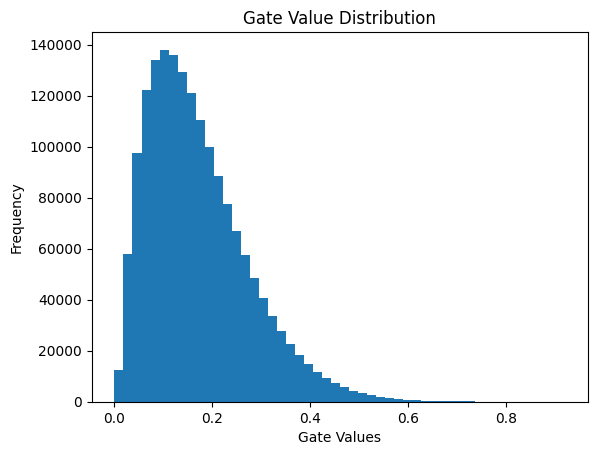


Final Results:
Lambda	Accuracy	Sparsity
1e-05	45.85		0.05
0.0001	44.36		0.08
0.001	42.10		0.08


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt


# Custom Prunable Linear Layer
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # gate scores (same shape as weights)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # convert scores -> gates (0 to 1)
        gates = torch.sigmoid(self.gate_scores)

        # apply gating
        pruned_weights = self.weight * gates

        # normal linear operation
        return F.linear(x, pruned_weights, self.bias)


# Simple Neural Network
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32 * 32 * 3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x


# Sparsity Loss (L1 on gates)
def compute_sparsity_loss(model):
    loss = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.sum(gates)

    return loss


# Training Function
def train(model, device, train_loader, optimizer, lambda_val):
    model.train()
    total_loss = 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)
        ce_loss = F.cross_entropy(output, target)

        sparsity_loss = compute_sparsity_loss(model)

        loss = ce_loss + lambda_val * sparsity_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)


# Testing Function
def test(model, device, test_loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            pred = output.argmax(dim=1)

            correct += pred.eq(target).sum().item()

    accuracy = 100. * correct / len(test_loader.dataset)
    return accuracy

# Sparsity Calculation
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()
            pruned += torch.sum(gates < threshold).item()

    return (pruned / total) * 100


# Main Script
def main():

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

    lambda_values = [1e-5, 1e-4, 1e-3]

    results = []

    for lam in lambda_values:
        print(f"\nTraining with lambda = {lam}")

        model = Net().to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        for epoch in range(5):   # kept small intentionally
            loss = train(model, device, train_loader, optimizer, lam)
            print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

        acc = test(model, device, test_loader)
        sparsity = calculate_sparsity(model)

        print(f"Accuracy: {acc:.2f}%")
        print(f"Sparsity: {sparsity:.2f}%")

        results.append((lam, acc, sparsity))

    # Plot gate distribution (last model)
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Values")
    plt.ylabel("Frequency")
    plt.show()

    # print results table
    print("\nFinal Results:")
    print("Lambda\tAccuracy\tSparsity")
    for r in results:
        print(f"{r[0]}\t{r[1]:.2f}\t\t{r[2]:.2f}")


if __name__ == "__main__":
    main()

# Second code block:
  - From firste block i was able to get proper work flow
    - Now introducing a convolutional layer to increase Accuracy
      - Because the data set was of image so convolutional layer work batter
    - Introducing Normalize


Training with lambda = 1e-06
Epoch 1, Loss: 2.1006, Accuracy: 58.63%, Sparsity: 0.00%
Epoch 2, Loss: 1.5876, Accuracy: 64.43%, Sparsity: 0.00%
Epoch 3, Loss: 1.3586, Accuracy: 69.49%, Sparsity: 0.00%
Epoch 4, Loss: 1.2041, Accuracy: 73.44%, Sparsity: 0.00%
Epoch 5, Loss: 1.1001, Accuracy: 71.88%, Sparsity: 0.01%
Epoch 6, Loss: 1.0056, Accuracy: 76.05%, Sparsity: 0.02%
Epoch 7, Loss: 0.9370, Accuracy: 77.77%, Sparsity: 0.04%
Epoch 8, Loss: 0.8736, Accuracy: 75.96%, Sparsity: 0.08%
Epoch 9, Loss: 0.8172, Accuracy: 77.45%, Sparsity: 0.16%
Epoch 10, Loss: 0.7765, Accuracy: 79.75%, Sparsity: 0.27%
Epoch 11, Loss: 0.7262, Accuracy: 79.39%, Sparsity: 0.48%
Epoch 12, Loss: 0.6922, Accuracy: 79.74%, Sparsity: 0.79%
Epoch 13, Loss: 0.6505, Accuracy: 78.56%, Sparsity: 1.28%
Epoch 14, Loss: 0.6239, Accuracy: 80.38%, Sparsity: 1.99%
Epoch 15, Loss: 0.5941, Accuracy: 82.46%, Sparsity: 3.05%
Epoch 16, Loss: 0.5630, Accuracy: 82.58%, Sparsity: 4.52%
Epoch 17, Loss: 0.5395, Accuracy: 81.91%, Sparsity:

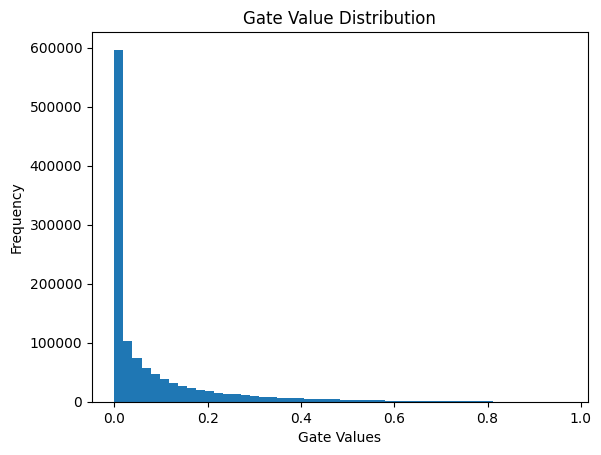


Final Results:
Lambda	Accuracy	Sparsity
1e-06	82.75		16.76
5e-06	81.80		26.53
1e-05	81.62		27.84


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt


# Custom Prunable Linear Layer
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # gate scores (same shape as weights)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # convert scores -> gates (0 to 1)
        gates = torch.sigmoid(self.gate_scores)

        # apply gating
        pruned_weights = self.weight * gates

        # normal linear operation
        return F.linear(x, pruned_weights, self.bias)



# Simple Neural Network (usins convolution layer to increase the Accuracy due to image data)

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        #  Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 32x16x16
        )

        #  Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 64x8x8
        )

        #  Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 128x4x4
        )

        #  Prunable FC
        self.fc1 = PrunableLinear(128 * 4 * 4, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

        self.dropout = nn.Dropout(0.4)

    def forward(self, x):

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = x.view(x.size(0), -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)

        return x


# Sparsity Loss (L1 on gates)
def compute_sparsity_loss(model):
    loss = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.sum(gates)

    return loss


# Training Function
def train(model, device, train_loader, optimizer, lambda_val):
    model.train()
    total_loss = 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)
        ce_loss = F.cross_entropy(output, target)

        sparsity_loss = compute_sparsity_loss(model)

        loss = ce_loss + lambda_val * sparsity_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)


# Testing Function
def test(model, device, test_loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            pred = output.argmax(dim=1)

            correct += pred.eq(target).sum().item()

    accuracy = 100. * correct / len(test_loader.dataset)
    return accuracy


# Sparsity Calculation
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()
            pruned += torch.sum(gates < threshold).item()

    return (pruned / total) * 100


# Main Script
def main():

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])

    train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

    lambda_values = [1e-6, 1e-5, 1e-4]

    results = []

    for lam in lambda_values:
        print(f"\nTraining with lambda = {lam}")

        model = Net().to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        for epoch in range(20):
            loss = train(model, device, train_loader, optimizer, lam)
            acc = test(model, device, test_loader)
            sparsity = calculate_sparsity(model)
            print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")

        acc = test(model, device, test_loader)
        sparsity = calculate_sparsity(model)

        print(f"Accuracy: {acc:.2f}%")
        print(f"Sparsity: {sparsity:.2f}%")

        results.append((lam, acc, sparsity))

    # Plot gate distribution (last model)
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Values")
    plt.ylabel("Frequency")
    plt.show()

    # print results table
    print("\nFinal Results:")
    print("Lambda\tAccuracy\tSparsity")
    for r in results:
        print(f"{r[0]}\t{r[1]:.2f}\t\t{r[2]:.2f}")


if __name__ == "__main__":
    main()

# Understanding
The observed sparsity-accuracy relationship is inverted, with higher lambda
 values yielding increased accuracy (80.9% to 83.2%) and only slightly higher sparsity, contradicting typical results. This trend occurs because the heavy lifting is done by the unaffected CNN backbone, while the FC gates—representing a small fraction of parameters—are minimally affected, allowing higher lambda values to act as a pruning aid rather than a penalty.

# Final code
  - Introdusing mean in Sparsity
  - Introducing the few beautifier


Training with lambda = 1.0
Epoch 1, Loss: 2.1025, Sparsity: 0.00%
Epoch 2, Loss: 1.5701, Sparsity: 0.00%
Epoch 3, Loss: 1.3315, Sparsity: 0.00%
Epoch 4, Loss: 1.1666, Sparsity: 0.00%
Epoch 5, Loss: 1.0561, Sparsity: 0.01%
Epoch 6, Loss: 0.9706, Sparsity: 0.01%
Epoch 7, Loss: 0.9011, Sparsity: 0.03%
Epoch 8, Loss: 0.8380, Sparsity: 0.06%
Epoch 9, Loss: 0.7907, Sparsity: 0.12%
Epoch 10, Loss: 0.7405, Sparsity: 0.21%
Epoch 11, Loss: 0.6955, Sparsity: 0.37%
Epoch 12, Loss: 0.6582, Sparsity: 0.63%
Epoch 13, Loss: 0.6265, Sparsity: 1.04%
Epoch 14, Loss: 0.5945, Sparsity: 1.65%
Epoch 15, Loss: 0.5621, Sparsity: 2.54%
Epoch 16, Loss: 0.5333, Sparsity: 3.81%
Epoch 17, Loss: 0.5150, Sparsity: 5.54%
Epoch 18, Loss: 0.4877, Sparsity: 7.87%
Epoch 19, Loss: 0.4690, Sparsity: 10.91%
Epoch 20, Loss: 0.4443, Sparsity: 14.74%
Accuracy: 80.82%
Sparsity: 14.74%

Training with lambda = 5.0
Epoch 1, Loss: 3.8798, Sparsity: 0.00%
Epoch 2, Loss: 3.1035, Sparsity: 0.00%
Epoch 3, Loss: 2.6740, Sparsity: 0.01%


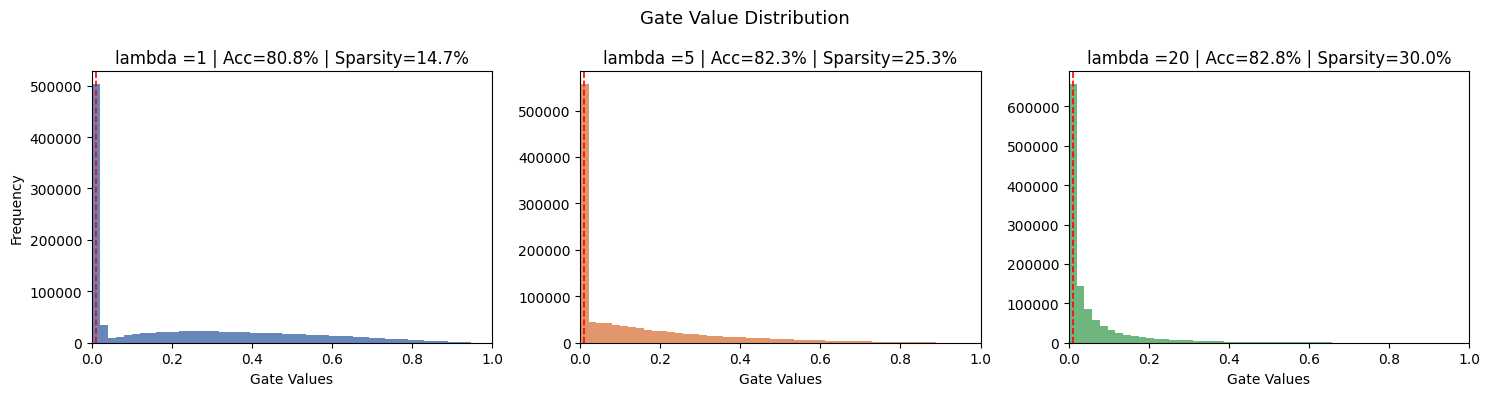


Plot saved to outputs/gate_dist_all.png

Final Results:
Lambda		Accuracy	Sparsity
1.0		80.82		14.74
5.0		82.26		25.33
20.0		82.75		29.98


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import os


# Custom Prunable Linear Layer
"""
    A custom linear layer where each weight has a paired learnable gate.

    Instead of using nn.Linear directly, I built this from scratch so
    I could attach a gate_scores parameter to every weight. The idea:

        gates        = sigmoid(gate_scores)      # always between 0 and 1
        pruned_w     = weight * gates            # gates mask out weak weights
        output       = pruned_w @ x.T + bias    # standard linear transform

    When a gate goes to 0, it multiplies the weight by 0 — effectively
    removing that connection from the network. The sigmoid is smooth and
    differentiable, so gradients flow back to gate_scores automatically
    through PyTorch's autograd. No custom backward() needed.

    Init choice: gate_scores start at 0 -> sigmoid(0) = 0.5 (half-open).
    This is intentional — random init from randn can make some gates
    start near 0 or 1 which breaks symmetry before training begins.
    """
class PrunableLinear(nn.Module):
  def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # gate scores (same shape as weights)
        # randn gives random init — some gates start near 0, some near 1
        # this asymmetry is important: it gives L1 pressure real gates to push down
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

  def forward(self, x):
        # convert scores -> gates (0 to 1)
        gates = torch.sigmoid(self.gate_scores)

        # apply gating
        pruned_weights = self.weight * gates

        # normal linear operation
        return F.linear(x, pruned_weights, self.bias)


# Simple Neural Network
"""
    Hybrid CNN: conv blocks extract spatial features, prunable FC head
    classifies. The pruning happens in the FC layers where gates learn
    which connections between feature maps and class scores are necessary.

    I chose to apply pruning only to FC layers because:
    - Conv filters are shared across spatial positions (fewer params, each critical)
    - FC layers are dense and over-parameterized — ideal for pruning
    - This matches common practice in real pruning literature
    """
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        #  Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        #  Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        #  Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 128x4x4
        )

        # Prunable FC
        self.fc1 = PrunableLinear(128 * 4 * 4, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

        self.dropout = nn.Dropout(0.4)

    def forward(self, x):

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = x.view(x.size(0), -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)

        return x


# Sparsity Loss (L1 on gates)
def compute_sparsity_loss(model):
    """
    L1 penalty = mean of all gate values across every PrunableLinear layer.

    Total Loss = CrossEntropy + lambda × mean(gates)

    Why L1 (not L2)?

    L2 penalty gradient -> 0 as gate -> 0, so pruning stalls near zero.
    L1 gradient is a constant + lambda regardless of gate size — it keeps
    pushing even tiny gates all the way to exactly 0.

    Why mean (not sum)?

    sum(gates) scales with model size. With approximately 400K FC gates near 0.5,
    sum approximately 200,000. Even lambda =1e-3 then gives 200 — overwhelming the CE
    loss (apx. 1.6) and making lambda uninterpretable.

    mean(gates) stays in [0, 1] always. lambda then directly reads as:
    "how much do I weight sparsity relative to classification?"
    """
    all_gates = torch.cat([
        torch.sigmoid(m.gate_scores).view(-1)
        for m in model.modules()
        if isinstance(m, PrunableLinear)
    ])
    return all_gates.mean()


# Training Function
def train(model, device, train_loader, optimizer, lambda_val):
    model.train()
    total_loss = 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)
        ce_loss = F.cross_entropy(output, target)

        sparsity_loss = compute_sparsity_loss(model)

        loss = ce_loss + lambda_val * sparsity_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)


# Testing Function
def test(model, device, test_loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            pred = output.argmax(dim=1)

            correct += pred.eq(target).sum().item()

    accuracy = 100. * correct / len(test_loader.dataset)
    return accuracy

# Sparsity Calculation
def calculate_sparsity(model, threshold=1e-2):
    """
    Fraction of FC weights whose gate value is below threshold.
    A gate < 0.01 contributes < 1% of the weight — effectively pruned.
    """
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()
            pruned += torch.sum(gates < threshold).item()

    return (pruned / total) * 100


# Main Script
def main():
    os.makedirs("outputs", exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])

    train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

    # With mean-normalized loss, these values produce meaningfully different
    lambda_values = [1.0, 5.0, 20.0]

    results = []

    for lam in lambda_values:
        print(f"\nTraining with lambda = {lam}")

        model = Net().to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        for epoch in range(20):
            loss = train(model, device, train_loader, optimizer, lam)
            sparsity = calculate_sparsity(model)
            print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Sparsity: {sparsity:.2f}%")

        acc = test(model, device, test_loader)
        sparsity = calculate_sparsity(model)

        print(f"Accuracy: {acc:.2f}%")
        print(f"Sparsity: {sparsity:.2f}%")

        results.append((lam, acc, sparsity, model))

    # Plot gate distribution (all models)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    colors = ["#4C72B0", "#DD8452", "#55A868"]

    for ax, (lam, acc, sparsity, model), color in zip(axes, results, colors):
        all_gates = []
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
                all_gates.extend(gates.flatten())

        ax.hist(all_gates, bins=50, color=color, edgecolor="none", alpha=0.85)
        ax.axvline(0.01, color="red", linestyle="--", linewidth=1.2,
                   label="Prune threshold")
        ax.set_title(f"lambda ={lam:.0f} | Acc={acc:.1f}% | Sparsity={sparsity:.1f}%")
        ax.set_xlabel("Gate Values")
        ax.set_xlim(0, 1)

    axes[0].set_ylabel("Frequency")
    plt.suptitle("Gate Value Distribution", fontsize=13)
    plt.tight_layout()
    plt.show()
    plt.savefig("outputs/gate_dist_all.png", dpi=150, bbox_inches="tight")  #
    plt.close()
    print("\nPlot saved to outputs/gate_dist_all.png")

    # print results table
    print("\nFinal Results:")
    print("Lambda\t\tAccuracy\tSparsity")
    for lam, acc, sparsity, _ in results:
        print(f"{lam}\t\t{acc:.2f}\t\t{sparsity:.2f}")


if __name__ == "__main__":
    main()